# 02 — Checking the cleaned data

**Phase 2, Step 2.** `src/clean_data.py` produced `data/processed/heart_clean.csv`.
This notebook does not change any data. It answers three questions:

1. **Did cleaning change only what the decision log says it changed?** Every
   difference between raw and clean should be explained by a decision (D1–D8
   in the README), and nothing else.
2. **Can a cleaned row be traced back to its raw line?** Spot-check a few
   records by `record_id`.
3. **Where is data missing?** A picture of the missing-value pattern, which
   decides what Phase 3 can and can't analyse.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from clean_data import LABELS, RAW_COLUMNS, RENAME, load_clean, load_raw  # noqa: E402

raw = load_raw()  # raw files with '?' read as missing, plus record_id and site
clean = load_clean()  # the CSV with analysis types restored
print(f"raw:   {raw.shape[0]} rows x {raw.shape[1]} columns")
print(f"clean: {clean.shape[0]} rows x {clean.shape[1]} columns")

raw:   920 rows x 16 columns
clean: 920 rows x 18 columns


## 1. Reconciliation: what changed between raw and clean?

The cleaned file has the same 920 rows in the same order, so we can line them
up by `record_id` and count, for every column, how many values are present
before and after cleaning. If a count changes, a decision must explain it.

In [2]:
assert (raw["record_id"] == clean["record_id"]).all(), "row order differs"

rows = []
for col in RAW_COLUMNS:
    if col == "num":
        continue
    new = RENAME.get(col, col)
    rows.append({
        "raw column": col,
        "clean column": new,
        "present in raw": int(raw[col].notna().sum()),
        "present in clean": int(clean[new].notna().sum()),
    })
recon = pd.DataFrame(rows)
recon["lost"] = recon["present in raw"] - recon["present in clean"]
recon

,raw column,clean column,present in raw,present in clean,lost
0,age,age,920,920,0
1,sex,sex,920,920,0
2,cp,chest_pain_type,920,920,0
3,trestbps,resting_bp,861,860,1
4,chol,cholesterol,890,718,172
5,fbs,fasting_blood_sugar_gt_120,830,830,0
6,restecg,resting_ecg,918,918,0
7,thalach,max_heart_rate,865,865,0
8,exang,exercise_angina,865,865,0
9,oldpeak,st_depression,858,858,0


Only two columns lost values, and both are decision **D2** (zeros that meant
"not measured"). Let's confirm the lost values are exactly the zeros and
nothing else:

In [3]:
for col, new in [("chol", "cholesterol"), ("trestbps", "resting_bp")]:
    became_missing = raw[col].notna() & clean[new].isna()
    were_zero = raw[col] == 0
    assert (became_missing == were_zero).all()
    print(f"{col:>8}: {became_missing.sum():>3} values removed, all of them were 0 in raw")

    chol: 172 values removed, all of them were 0 in raw
trestbps:   1 values removed, all of them were 0 in raw


Numeric columns that were *kept* must be unchanged. Integers were stored as
whole numbers (D4), so compare values rather than text:

In [4]:
numeric = {"age": "age", "trestbps": "resting_bp", "chol": "cholesterol",
           "thalach": "max_heart_rate", "oldpeak": "st_depression", "ca": "major_vessels"}
for col, new in numeric.items():
    both = raw[col].notna() & clean[new].notna()
    assert np.allclose(raw.loc[both, col], clean.loc[both, new]), col
print("All kept numeric values identical to raw.")

All kept numeric values identical to raw.


Decoded categories (D4) must map one-to-one back to the documented codes. A
cross-tab of raw code against clean label should have exactly one non-zero
cell per row:

In [5]:
for col, mapping in LABELS.items():
    new = RENAME.get(col, col)
    xt = pd.crosstab(raw[col], clean[new])
    assert ((xt > 0).sum(axis=1) == 1).all(), col
    for code_, label in mapping.items():
        if code_ in xt.index:
            assert xt.loc[code_, label] == xt.loc[code_].sum(), (col, code_)
print("Every code maps to exactly its documented label.")
pd.crosstab(raw["cp"], clean["chest_pain_type"])  # one example

Every code maps to exactly its documented label.


chest_pain_type,typical angina,atypical angina,non-anginal pain,asymptomatic
cp,,,,
1.0,46,0,0,0
2.0,0,174,0,0
3.0,0,0,204,0
4.0,0,0,0,496


Finally the target (**D3**). `disease` should equal `num ≥ 1` everywhere;
`severity` should equal `num` except for the Hungarian positives, which are
blank because their original severity is unknown.

In [6]:
assert (clean["disease"] == (raw["num"] > 0)).all()
pd.crosstab([raw["site"], raw["num"]], clean["severity"].fillna(-1).astype(int)
            .replace({-1: "blank"}), dropna=False).loc[["hungarian", "cleveland"]]

severity         0   1   2   3   4  blank
site      num                            
hungarian 0    188   0   0   0   0      0
          1      0   0   0   0   0    106
          2      0   0   0   0   0      0
          3      0   0   0   0   0      0
          4      0   0   0   0   0      0
cleveland 0    164   0   0   0   0      0
          1      0  55   0   0   0      0
          2      0   0  36   0   0      0
          3      0   0   0  35   0      0
          4      0   0   0   0  13      0

Hungarian positives (`num` = 1) all land in *blank*; Cleveland keeps its full
0–4 scale. Every difference between raw and clean is accounted for by a
logged decision.

## 2. Traceability spot-check

Pick a few random records and print the cleaned row next to the exact line
from the raw file named by its `record_id`.

In [7]:
SITE_FILES = {"cleveland": "processed.cleveland.data", "hungarian": "processed.hungarian.data",
              "switzerland": "processed.switzerland.data", "va": "processed.va.data"}

for rid in clean.sample(3, random_state=7)["record_id"]:
    site, line_no = rid.rsplit("-", 1)
    raw_line = (ROOT / "data" / "raw" / SITE_FILES[site]).read_text().splitlines()[int(line_no) - 1]
    print(rid)
    print("  raw line :", raw_line)
    print("  cleaned  :", clean.loc[clean["record_id"] == rid].drop(columns=["record_id"]).iloc[0].to_dict())
    print()

va-119
  raw line : 59,1,4,125,222,0,0,135,1,2.5,3,?,?,3
  cleaned  : {'site': 'va', 'age': 59, 'sex': 'male', 'chest_pain_type': 'asymptomatic', 'resting_bp': 125, 'cholesterol': 222, 'fasting_blood_sugar_gt_120': False, 'resting_ecg': 'normal', 'max_heart_rate': 135, 'exercise_angina': True, 'st_depression': 2.5, 'st_slope': 'downsloping', 'major_vessels': None, 'thallium_result': nan, 'disease': True, 'severity': 3, 'possible_duplicate': False}

hungarian-028
  raw line : 38,0,2,120,275,?,0,129,0,0,?,?,?,0
  cleaned  : {'site': 'hungarian', 'age': 38, 'sex': 'female', 'chest_pain_type': 'atypical angina', 'resting_bp': 120, 'cholesterol': 275, 'fasting_blood_sugar_gt_120': None, 'resting_ecg': 'normal', 'max_heart_rate': 129, 'exercise_angina': False, 'st_depression': 0.0, 'st_slope': nan, 'major_vessels': None, 'thallium_result': nan, 'disease': False, 'severity': 0, 'possible_duplicate': False}

switzerland-110
  raw line : 65,1,4,155,0,?,0,154,0,1,1,?,?,0
  cleaned  : {'site': 's

## 3. Where is data missing?

Percent missing per column and site, after cleaning (so the zero-coded
cholesterol now counts as missing). Darker = more missing.

In [8]:
features = ["age", "sex", "chest_pain_type", "resting_bp", "cholesterol",
            "fasting_blood_sugar_gt_120", "resting_ecg", "max_heart_rate", "exercise_angina",
            "st_depression", "st_slope", "major_vessels", "thallium_result", "severity"]
site_names = {"cleveland": "Cleveland", "hungarian": "Hungarian",
              "switzerland": "Switzerland", "va": "VA Long Beach"}
pct = (clean[features].isna().groupby(clean["site"], sort=False).mean().mul(100)
       .T.rename(columns=site_names))
pct.round(0).astype(int)

site,Cleveland,Hungarian,Switzerland,VA Long Beach
age,0,0,0,0
sex,0,0,0,0
chest_pain_type,0,0,0,0
resting_bp,0,0,2,28
cholesterol,0,8,100,28
fasting_blood_sugar_gt_120,0,3,61,4
resting_ecg,0,0,1,0
max_heart_rate,0,0,1,26
exercise_angina,0,0,1,26
st_depression,0,0,5,28


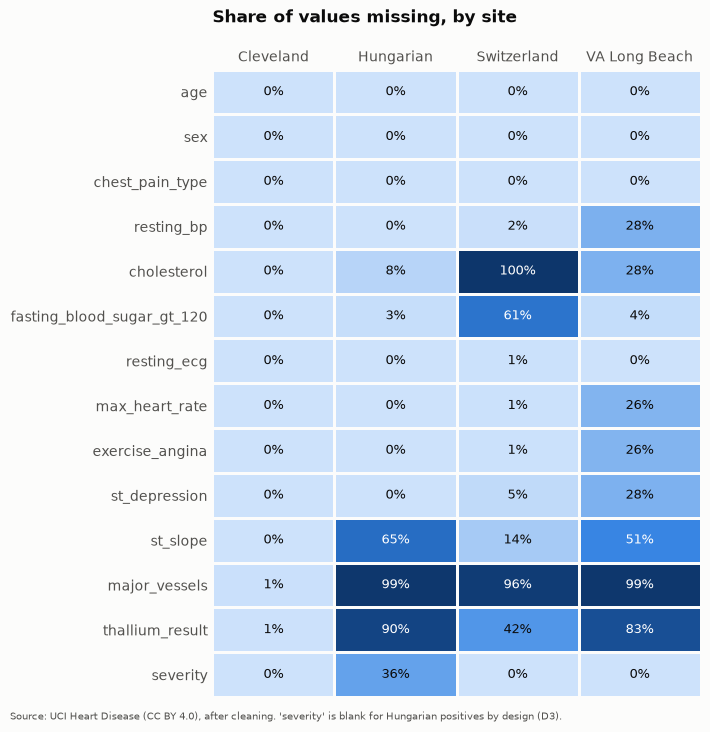

In [9]:
# Single-hue sequential ramp (light = little missing, dark = mostly missing).
from matplotlib.colors import LinearSegmentedColormap

RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SURFACE, INK, INK_2 = "#fcfcfb", "#0b0b0b", "#52514e"
cmap = LinearSegmentedColormap.from_list("missing", RAMP)

fig, ax = plt.subplots(figsize=(7.2, 7.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
values = pct.to_numpy()
# edgecolor = surface draws the 2px gap between cells
ax.pcolormesh(values, cmap=cmap, vmin=0, vmax=100, edgecolors=SURFACE, linewidth=2)
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        v = values[i, j]
        ax.text(j + 0.5, i + 0.5, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                color="white" if v >= 45 else INK)

ax.set_xticks(np.arange(values.shape[1]) + 0.5, pct.columns, color=INK_2)
ax.set_yticks(np.arange(values.shape[0]) + 0.5, pct.index, color=INK_2)
ax.xaxis.tick_top()
ax.invert_yaxis()
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Share of values missing, by site", loc="left", color=INK,
             fontsize=12, fontweight="bold", pad=34)
fig.text(0.02, 0.02, "Source: UCI Heart Disease (CC BY 4.0), after cleaning. "
         "'severity' is blank for Hungarian positives by design (D3).",
         fontsize=7.5, color=INK_2)
fig.tight_layout(rect=(0, 0.03, 1, 1))
out = ROOT / "reports" / "figures" / "missing_by_site.png"
fig.savefig(out, dpi=200, facecolor=SURFACE)
plt.show()

### What the picture says

- **Cleveland is essentially complete.** Every other site has large gaps.
- **`major_vessels` and `thallium_result` exist almost only at Cleveland**
  (96–99% and 42–90% missing elsewhere). Any analysis using them is a
  Cleveland analysis, whatever the dataset is called.
- **Cholesterol is entirely missing for Switzerland** — the zeros from D2.
- **`st_slope` is patchy everywhere except Cleveland** (14–65% missing).
- **The core measurements** (age, sex, chest pain type, blood pressure, max
  heart rate, exercise angina, ST depression) are present for 72–100% of rows
  at every site; these are the variables a four-site comparison can use.

This is why the Phase 3 choice is between **Cleveland only** (all 13
predictors, 303 patients) and **all four sites** (fewer predictors, 920
patients, with site-level differences to account for).